In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
print("Pobieranie danych (QM9)...")
ds = load_dataset("yairschiff/qm9", split="train")
ds_split = ds.train_test_split(test_size=0.1, seed=1)

# Definiujemy początkowy zestaw 16 zmiennych
initial_features = [
    'logP', 'qed', 'np_score', 'sa_score', 'ring_count', 
    'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 
    'single_bond', 'double_bond', 'triple_bond', 'aromatic_bond'
]
target = 'gap'

df_train = ds_split["train"].to_pandas()
print(f"Pobrano {len(df_train)} próbek treningowych. Liczba cech początkowych: {len(initial_features)}")

Pobieranie danych (QM9)...


Pobrano 120496 próbek treningowych. Liczba cech początkowych: 16


Generowanie macierzy korelacji dla pełnego zbioru...


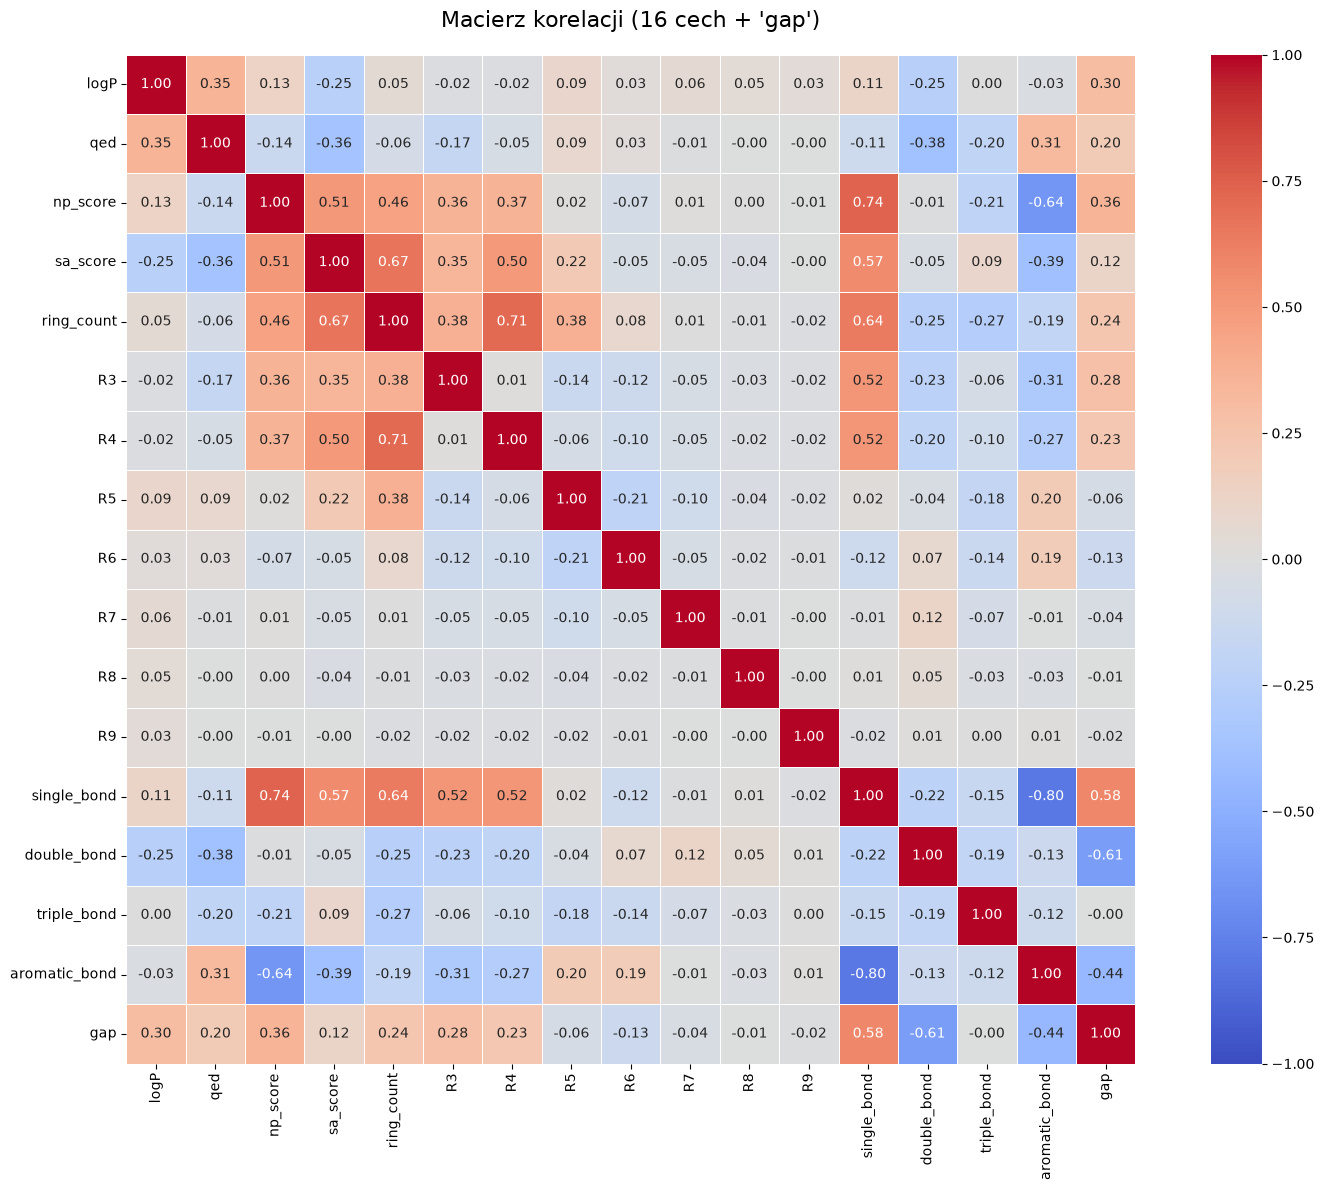

In [3]:
print("Generowanie macierzy korelacji dla pełnego zbioru...")
cols_to_analyze = initial_features + [target]
corr_matrix = df_train[cols_to_analyze].corr()

plt.figure(figsize=(16, 12))  
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    center=0, 
    linewidths=0.5, 
    square=True
)
plt.title("Macierz korelacji (16 cech + 'gap')", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [4]:
print("Odrzucanie bezużytecznych cech i tworzenie DataLoaderów...")

# wyrzucamy R7, R8, R9 oraz triple_bond
final_features = [
    'logP', 'qed', 'np_score', 'sa_score', 'ring_count', 
    'R3', 'R4', 'R5', 'R6', 'single_bond', 'double_bond', 'aromatic_bond'
]

X_train_raw = df_train[final_features].values
y_train_raw = df_train[target].values

# Standaryzacja (średnia 0, wariancja 1) dla wybranych 12 cech TYLKO DLA TRNINGOWEGO ZEBY ZAPOBIEC DATA LEAKAGE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

# Konwersja na Tensory float32
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_raw, dtype=torch.float32).view(-1, 1)

batch_size = 256
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
print(f"Kształt wejścia X do modelu: {X_train_tensor.shape}")

Odrzucanie bezużytecznych cech i tworzenie DataLoaderów...
Kształt wejścia X do modelu: torch.Size([120496, 12])


W sieci MLP, każda warstwa próbuje nauczyć się pewnej transformacji wejścia $x$. Możemy to zapisać jako:

$$\mathcal{H}(x) = \mathcal{F}(x)$$

Gdzie $\mathcal{F}(x)$ to operacje warstwy (mnożenie przez wagi i funkcja aktywacji). Podczas propagacji wstecznej, gradient przechodzi przez tę funkcję. Jeśli wagi są małe, pochodna $\frac{\partial \mathcal{F}}{\partial x}$ również jest ułamkiem bliskim zera. Mnożenie tak malych wartości przez 15 warstw prowadzi do **zaniku gradientu**.

Architektura **ResNet** zamiast zmuszać warstwę do nauki pełnej transformacji, dodajemy do jej wyjścia oryginalne wejście $x$ dzięki temu sieć nie uczy się przewidywać wartości targetu, a reszty, którą trzeba dodać do wejścia aby go otrzymać stąd nazwa **ResNet** od residual

$$\mathcal{H}(x) = \mathcal{F}(x) + x$$

Gdy policzymy pochodną (gradient) tego równania mamy:

$$\frac{\partial \mathcal{H}}{\partial x} = \frac{\partial \mathcal{F}}{\partial x} + 1$$

$+ 1$ na końcu równania sprawia, że nawet jeśli gradient się wyzeruje sygnał błędu i tak przepłynie w głąb sieci.

In [5]:
class DeepMLP(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, num_layers=15):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(num_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(dim, dim), nn.ReLU(), nn.Linear(dim, dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.layer(x) + x)

class DeepResNet(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, num_blocks=15):
        super().__init__()
        self.input_layer = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU())
        blocks = [ResidualBlock(hidden_dim) for _ in range(num_blocks)]
        self.res_blocks = nn.Sequential(*blocks)
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.output_layer(self.res_blocks(self.input_layer(x)))

# Inicjalizacja modeli
model_deep_mlp = DeepMLP()
model_deep_resnet = DeepResNet()

criterion = nn.MSELoss()
optimizer_mlp = optim.SGD(model_deep_mlp.parameters(), lr=0.01)
optimizer_resnet = optim.SGD(model_deep_resnet.parameters(), lr=0.01)
print("Modele zdefiniowane i gotowe do uczenia.")

Modele zdefiniowane i gotowe do uczenia.


In [6]:
epochs = 15
hist_epochs, hist_loss_mlp, hist_loss_resnet, hist_grad_mlp, hist_grad_resnet = [], [], [], [], []

print("Trening...\n")
for epoch in range(epochs):
    model_deep_mlp.train()
    model_deep_resnet.train()
    
    train_loss_mlp, train_loss_resnet = 0.0, 0.0
    first_batch = True 
    
    for X_batch, y_batch in train_loader:
        # Trening MLP
        optimizer_mlp.zero_grad()
        loss_mlp = criterion(model_deep_mlp(X_batch), y_batch)
        loss_mlp.backward()
        
        # Pobieranie gradientu
        if first_batch:
            grad_mlp = model_deep_mlp.net[0].weight.grad.norm().item()
            
        optimizer_mlp.step()
        train_loss_mlp += loss_mlp.item()
        
        # Trening ResNet
        optimizer_resnet.zero_grad()
        loss_resnet = criterion(model_deep_resnet(X_batch), y_batch)
        loss_resnet.backward()
        
        # Pobieranie gradientu
        if first_batch:
            grad_resnet = model_deep_resnet.input_layer[0].weight.grad.norm().item()
            
        optimizer_resnet.step()
        train_loss_resnet += loss_resnet.item()
        
        first_batch = False
        
    avg_loss_mlp = train_loss_mlp / len(train_loader)
    avg_loss_resnet = train_loss_resnet / len(train_loader)
    
    # Zapis danych do list
    hist_epochs.append(epoch + 1)
    hist_loss_mlp.append(avg_loss_mlp)
    hist_loss_resnet.append(avg_loss_resnet)
    hist_grad_mlp.append(grad_mlp)
    hist_grad_resnet.append(grad_resnet)
    
    print(f"Epoka [{epoch+1}/{epochs}] | Loss MLP: {avg_loss_mlp:.4f} | Loss ResNet: {avg_loss_resnet:.4f}")

Trening...

Epoka [1/15] | Loss MLP: 0.0034 | Loss ResNet: 0.0051
Epoka [2/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0021
Epoka [3/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0016
Epoka [4/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0014
Epoka [5/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0012
Epoka [6/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0011
Epoka [7/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0010
Epoka [8/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0010
Epoka [9/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0009
Epoka [10/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0009
Epoka [11/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0009
Epoka [12/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0008
Epoka [13/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0008
Epoka [14/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0008
Epoka [15/15] | Loss MLP: 0.0023 | Loss ResNet: 0.0008


Generowanie wykresów...


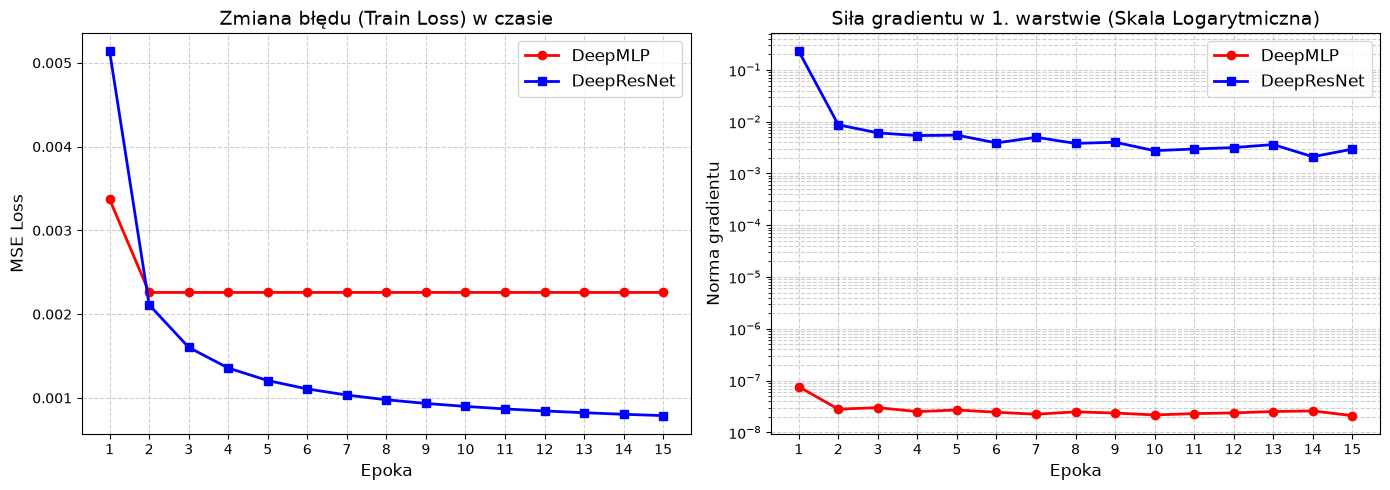

In [7]:
print("Generowanie wykresów...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Błąd (Loss)
ax1.plot(hist_epochs, hist_loss_mlp, label='DeepMLP', color='red', marker='o', linewidth=2)
ax1.plot(hist_epochs, hist_loss_resnet, label='DeepResNet', color='blue', marker='s', linewidth=2)
ax1.set_title('Zmiana błędu (Train Loss) w czasie', fontsize=14)
ax1.set_xlabel('Epoka', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.set_xticks(hist_epochs)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

# Wykres 2: Siła gradientu (oś Y logarytmiczna)
ax2.plot(hist_epochs, hist_grad_mlp, label='DeepMLP', color='red', marker='o', linewidth=2)
ax2.plot(hist_epochs, hist_grad_resnet, label='DeepResNet', color='blue', marker='s', linewidth=2)
ax2.set_title('Siła gradientu w 1. warstwie (Skala Logarytmiczna)', fontsize=14)
ax2.set_xlabel('Epoka', fontsize=12)
ax2.set_ylabel('Norma gradientu', fontsize=12)
ax2.set_yscale('log')
ax2.set_xticks(hist_epochs)
ax2.grid(True, linestyle='--', alpha=0.6, which='both')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
print("Przygotowanie zbioru testowego...")
df_test = ds_split["test"].to_pandas()

# Wyciągamy te same 12 cech
X_test_raw = df_test[final_features].values
y_test_raw = df_test[target].values

# Używamy ułożonego już skalera do przetransformowania nowych danych
X_test_scaled = scaler.transform(X_test_raw)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_raw, dtype=torch.float32).view(-1, 1)

# Zbiór testowy
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)
print(f"Dane testowe gotowe! Liczba próbek: {len(df_test)}")

Przygotowanie zbioru testowego...
Dane testowe gotowe! Liczba próbek: 13389


In [10]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

model_deep_mlp.eval()
model_deep_resnet.eval()

# Listy na wyniki
preds_mlp, preds_resnet, y_true = [], [], []

print("Wykonywanie przewidywań na zbiorze testowym...")

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Zapisujemy prawdziwe wartości
        y_true.extend(y_batch.numpy())
        
        # Przewidywania MLP
        preds_mlp.extend(model_deep_mlp(X_batch).numpy())
        
        # Przewidywania ResNet
        preds_resnet.extend(model_deep_resnet(X_batch).numpy())

# Konwersja list na tablice numpy
y_true = np.array(y_true).flatten()
preds_mlp = np.array(preds_mlp).flatten()
preds_resnet = np.array(preds_resnet).flatten()

# Obliczanie metryk
r2_mlp = r2_score(y_true, preds_mlp)
mae_mlp = mean_absolute_error(y_true, preds_mlp)

r2_resnet = r2_score(y_true, preds_resnet)
mae_resnet = mean_absolute_error(y_true, preds_resnet)

print("-" * 50)
print("WYNIKI NA ZBIORZE TESTOWYM:")
print("-" * 50)
print(f"DeepMLP    | R^2: {r2_mlp:.4f} | MAE: {mae_mlp:.4f}")
print(f"DeepResNet | R^2: {r2_resnet:.4f} | MAE: {mae_resnet:.4f}")
print("-" * 50)

Wykonywanie przewidywań na zbiorze testowym...
--------------------------------------------------
WYNIKI NA ZBIORZE TESTOWYM:
--------------------------------------------------
DeepMLP    | R^2: -0.0002 | MAE: 0.0395
DeepResNet | R^2: 0.6527 | MAE: 0.0218
--------------------------------------------------


Generowanie wykresów rzeczywiste vs przewidywane...


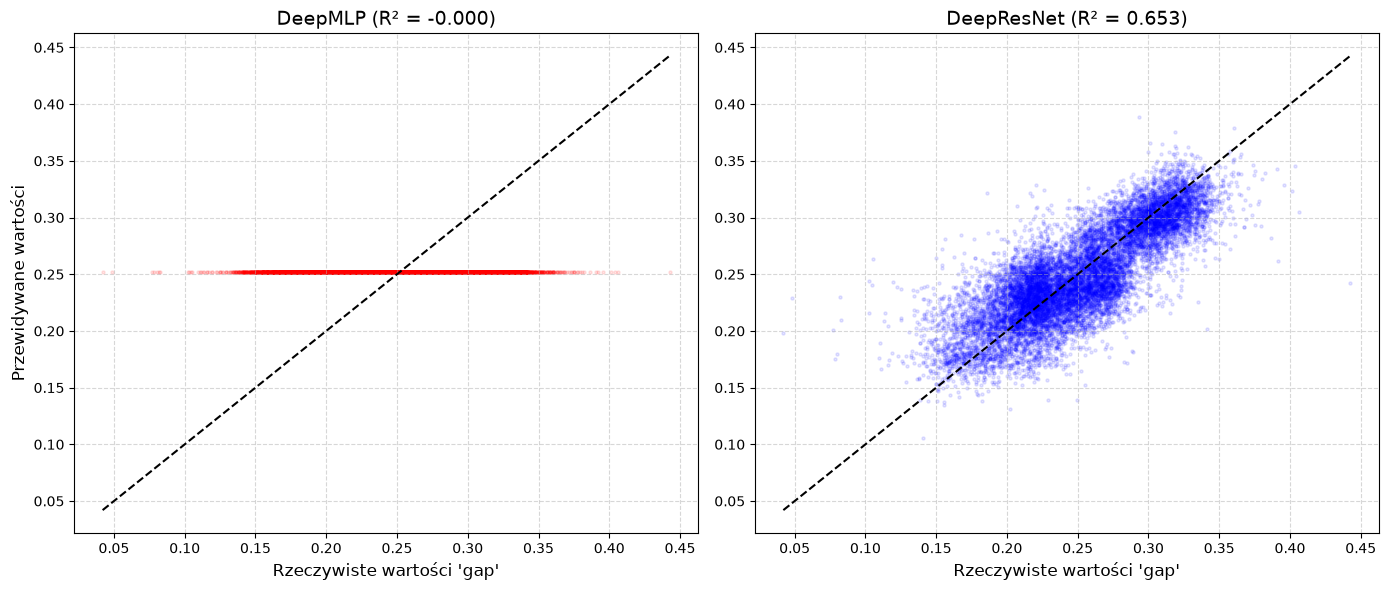

In [11]:
print("Generowanie wykresów rzeczywiste vs przewidywane...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Linia idealnego dopasowania (y = x)
min_val = min(y_true.min(), preds_resnet.min(), preds_mlp.min())
max_val = max(y_true.max(), preds_resnet.max(), preds_mlp.max())

# Wykres 1: DeepMLP
ax1.scatter(y_true, preds_mlp, alpha=0.1, color='red', s=5)
ax1.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
ax1.set_title(f"DeepMLP (R² = {r2_mlp:.3f})", fontsize=14)
ax1.set_xlabel("Rzeczywiste wartości 'gap'", fontsize=12)
ax1.set_ylabel("Przewidywane wartości", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# Wykres 2: DeepResNet
ax2.scatter(y_true, preds_resnet, alpha=0.1, color='blue', s=5)
ax2.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
ax2.set_title(f"DeepResNet (R² = {r2_resnet:.3f})", fontsize=14)
ax2.set_xlabel("Rzeczywiste wartości 'gap'", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()